# Human-in-the-Loop

The Human-in-the-Loop (HITL) pattern integrates human judgment into AI workflows. Agents handle routine cases autonomously, while high-risk actions are gated on explicit human approval.

## Implementation with Flyte v2 + the Agent harness

This refactor implements a real gate: the sensitive action — `issue_refund` — is a `@tool(requires_approval=True)`. When the agent decides to call it, the harness **pauses the run** via `flyteplugins-hitl` and waits for a human to approve or deny before the tool executes.

#### ADK vs Flyte v2 + Agent harness

| Aspect | ADK | Flyte v2 + `Agent` harness |
|--------|-----|----------------------------|
| **Escalation trigger** | `escalate_to_human` mock tool | `@tool(requires_approval=True)` — real pause-for-approval |
| **Approval transport** | Not shown | `flyteplugins-hitl` surfaces the request in the UI |
| **On denial** | N/A | Agent recovers and tries another approach |
| **Personalization** | `CallbackContext` injection | Customer context passed in the message |
| **Routine tools** | `troubleshoot_issue`, `create_ticket` | `@tool` functions — schema from type hints |
| **Secrets** | `os.environ` | `flyte.Secret` injected by cluster |

> **🧭 When to use this pattern — and how Flyte helps**
>
> Use human-in-the-loop where mistakes carry safety, ethical, or financial weight (healthcare, finance, autonomy), where nuance exceeds what the model handles reliably, or to capture high-quality human feedback. In Flyte, `@tool(requires_approval=True)` pauses the run via `flyteplugins-hitl` until a person approves or denies the gated action.

### 1. Install dependencies

In [ ]:
!uv pip install "flyte==2.5.4" litellm "flyteplugins-hitl==2.5.4"

### 2. Store your API key

In [ ]:
!flyte create secret ANTHROPIC_API_KEY --value sk-...

### 3. Import dependencies and configure the TaskEnvironment

In [1]:
import json
import os
import uuid
from dataclasses import dataclass, field
from datetime import timedelta

import flyte
import flyte.report

flyte.init_from_config()

import flyteplugins.hitl as hitl
from flyte.ai.agents import Agent, AgentResult, tool
from pydantic import BaseModel, Field
from typing import List


from flyte._image import _get_base_registry
from flyteplugins.hitl import _event as _hitl_event

_local_event_image = _hitl_event.event_image.clone(registry=_get_base_registry())
_hitl_event.event_image = _local_event_image
_hitl_event.event_app_env.image = _local_event_image
_hitl_event.event_task_env.image = _local_event_image

# The devbox runs insecure (localhost, no auth proxy / IdP), so the form app's default
# requires_auth=True makes the knative deployment fail. Disable it for the devbox; on a
# remote Union cluster leave it True so the approval form is authenticated.
_hitl_event.event_app_env.requires_auth = False
print("HITL event-app image ->", _hitl_event.event_app_env.image.uri,
      "| requires_auth ->", _hitl_event.event_app_env.requires_auth)

_image = (
    flyte.Image.from_debian_base(name="hitl-agent", python_version=(3, 12))
    .with_pip_packages("litellm", "flyteplugins-hitl")
)

hitl_env = flyte.TaskEnvironment(
    name="hitl_agent",
    image=_image,
    resources=flyte.Resources(cpu="1", memory="1Gi"),
    secrets=[
        flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY"),
    ],
    # The approval gate runs in the plugin's own environment (`hitl-event-task-env`,
    # which serves the approval web form). Declaring it here bundles and registers it
    # with this run; without it the gated tool call fails with
    # "Environment 'hitl-event-task-env' not found in image cache."
    depends_on=[hitl.env],
)

HITL event-app image -> localhost:30000/hitl-event-app-image:96ce691caa7b9a405fe75fc6382b6e6d | requires_auth -> False


In [2]:
# Deploy the HITL approval-form app from the client (once) so it EXISTS before the run.
#
# Why it's needed on the devbox: the in-pod new_event() can't stand the app up itself — its
# serve() hangs in App.watch(wait_for="activated") — so cell 10 skips serve() and instead
# points Event at the *already-deployed* app's endpoint. That only works if the app is already
# deployed, which is what this cell does (from the client, where serve's watch is worked around
# by polling App status rather than awaiting it). The form link the run shows resolves to this
# app; the human opens it to approve/deny. On a remote Union cluster none of this is needed.
import asyncio
from flyteplugins.hitl._event import event_app_env
from flyte.remote import App


def _app_active() -> bool:
    try:
        return App.get("hitl-event-app").is_active()
    except Exception:
        return False


if _app_active():
    print("HITL event app already deployed + ACTIVE — nothing to do.")
else:
    _deploy = asyncio.ensure_future(
        flyte.with_servecontext(copy_style="none", version=flyte.version()).serve.aio(event_app_env)
    )
    for _ in range(90):  # ~3 min max
        await asyncio.sleep(2)
        if _app_active():
            break
    _deploy.cancel()  # stop serve()'s lingering watch; the deploy RPC already went through
    print("HITL event app deployed. ACTIVE:", _app_active())

HITL event app already deployed + ACTIVE — nothing to do.


### 4. Define the customer context

`CustomerContext` is a typed task input — the agent receives the customer's tier and history and personalizes accordingly. There is no `SupportResult(escalate=...)` flag anymore: escalation is no longer a return value to interpret, it's an approval gate on the sensitive tool.

In [3]:
class CustomerContext(BaseModel):
    """Typed customer context passed to the support agent.

    Pydantic BaseModel, NOT a @dataclass: when run.outputs() reconstructs the task
    interface, Flyte rebuilds dataclasses from their JSON schema via make_dataclass, and
    `field(default_factory=list)` fields lose their default there -> "non-default argument
    follows default argument". BaseModel uses Flyte's pydantic transformer and round-trips
    cleanly through the guess-interface path.
    """
    name: str
    tier: str = "standard"           # "standard" | "premium" | "enterprise"
    recent_purchases: List[str] = Field(default_factory=list)
    support_history: List[str] = Field(default_factory=list)

### 5. Define the tools (one gated by human approval)

`troubleshoot_issue` and `create_ticket` are ordinary `@tool`s. `issue_refund` is the sensitive, irreversible action — marked `@tool(requires_approval=True)`, so the harness pauses for a human decision before it runs.

In [4]:
@tool
def troubleshoot_issue(issue: str, device_type: str = "") -> str:
    """Diagnose a technical issue and return step-by-step troubleshooting instructions.

    Args:
        issue: Description of the technical issue.
        device_type: Type of device, e.g. 'laptop' or 'phone'.
    """
    return (
        f"Troubleshooting for '{issue}' ({device_type or 'device'}): "
        "1) restart the device, 2) update firmware, 3) check cables/connections."
    )


@tool
def create_ticket(issue_type: str, details: str) -> str:
    """Create a support ticket and return its ID.

    Args:
        issue_type: Category of the issue.
        details: Full issue description for the ticket.
    """
    return f"TICKET-{uuid.uuid4().hex[:8].upper()} created for {issue_type}."


@tool(requires_approval=True)
def issue_refund(order_id: str, amount_usd: float) -> str:
    """Issue a refund for an order. High-risk and irreversible — requires human approval.

    Args:
        order_id: The order to refund.
        amount_usd: Refund amount in US dollars.
    """
    return f"Refund of ${amount_usd:.2f} issued for order {order_id}."


def _esc(text: str) -> str:
    return text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


async def gated_approval(tool: "AgentTool", args: dict) -> bool:
    """Surface the pause AND a clickable approval-form link in the task's report, then wait.

    There is no "Paused" action phase — the run stays Running while `event.wait()` polls
    object storage for the human's response. We create the event FIRST so its `form_url`
    (served by the hitl-event-app) is available to embed right here; click it to approve/deny.
    """
    # DEVBOX FIX (runs inside the task pod): the plugin's new_event() calls serve(), which
    # re-deploys the form app and then HANGS in App.watch(wait_for="activated") on the devbox —
    # the watch misses the PENDING->ACTIVE transition even though the app is Ready, so serve()
    # never returns, new_event() never returns, the report never flushes, and the run hangs
    # Running with no approval banner. The app is already deployed by the pre-deploy cell, so
    # seed Event with a handle pointing at its endpoint; Event.create() then skips _serve_app()
    # entirely (no in-pod build, no watch, no hang). On a remote Union cluster serve() works, so
    # this only kicks in when the app isn't already handled (Event._app_handle is None).
    from flyteplugins.hitl import _event as _he
    from flyte.remote import App as _App

    if _he.Event._app_handle is None:
        try:
            _ep = _App.get("hitl-event-app").endpoint
        except Exception:
            _ep = (
                f"http://hitl-event-app-{flyte.current_project()}-"
                f"{flyte.current_domain()}.localhost:30081"
            )
        _he.Event._app_handle = type("_AppHandle", (), {"endpoint": _ep})()
        _he.Event._app_served = True

    pretty_args = json.dumps(args, indent=2, default=str)

    # Create the event first so its form URL is available to show in the report.
    event = await hitl.new_event.aio(
        f"approve_{tool.name}_{uuid.uuid4().hex[:6]}",
        data_type=bool,
        scope="run",
        prompt=f"""Approve tool call `{tool.name}`?

Arguments:
{pretty_args}""",
    )

    await flyte.report.log.aio(
        "<div style='border:2px solid #d97706;background:#fffbeb;padding:12px;border-radius:8px'>"
        "<h2 style='margin:0;color:#b45309'>⏸ PAUSED — waiting for human approval</h2>"
        f"<p>The agent wants to call <code>{tool.name}</code> with:</p>"
        f"<pre>{_esc(pretty_args)}</pre>"
        f"<p><a href='{event.form_url}' target='_blank' "
        "style='display:inline-block;padding:8px 16px;background:#2563eb;color:#fff;"
        "border-radius:6px;text-decoration:none;font-weight:bold'>▶ Open approval form</a></p>"
        "<p style='font-size:0.9em;color:#555'>The run stays <b>Running</b> until you submit; "
        "you can also approve/deny from the <code>hitl-event-app</code> sub-action's Reports tab.</p>"
        "</div>"
    )
    await flyte.report.flush.aio()

    approved = await event.wait.aio()

    color, label = ("#15803d", "✅ APPROVED") if approved else ("#b91c1c", "🛑 DENIED")
    await flyte.report.log.aio(f"<h3 style='color:{color}'>{label} — {tool.name}</h3>")
    await flyte.report.flush.aio()
    return approved


support_bot = Agent(
    name="support",
    # claude-haiku-4-5 under-calls the gated tool: for the Eve scenario it would answer
    # directly instead of invoking issue_refund, so the approval gate never fires. A more
    # capable model reliably makes the deliberate tool call, so the run pauses for approval.
    model="claude-sonnet-4-6",
    instructions=(
        "You are a technical support specialist for an electronics company. Personalize using "
        "the customer context provided. Use troubleshoot_issue to diagnose problems and "
        "create_ticket to log unresolved ones. If the customer is clearly entitled to a refund "
        "(defective product, or troubleshooting failed for a premium/enterprise customer), call "
        "issue_refund — this pauses for human approval before executing. If approval is denied, "
        "apologize and create a ticket for manual follow-up instead."
    ),
    tools=[troubleshoot_issue, create_ticket, issue_refund],
    approval_callback=gated_approval,
    max_turns=10,
)

### 6. Define the support agent task

The task is thin: it packs the customer context into the message and runs the agent. When the agent calls `issue_refund`, the harness blocks the run on human approval — the escalation is enforced by the gate, not by an outer `if result.escalate` branch.

In [5]:
@hitl_env.task(
    retries=1,
    timeout=timedelta(minutes=10),
    cache=flyte.Cache(behavior="disable"),
    report=True,  # so gated_approval's "⏸ PAUSED" banner renders in the action's report tab
)
async def support_agent(issue: str, customer: CustomerContext) -> str:
    """Technical support agent with an approval-gated refund action."""
    context = (
        f"Customer: {customer.name} (tier: {customer.tier}). "
        f"Recent purchases: {', '.join(customer.recent_purchases) or 'none'}. "
        f"Past issues: {', '.join(customer.support_history) or 'none'}.\n\n"
        f"Issue: {issue}"
    )
    result: AgentResult = await support_bot.run.aio(context)
    return result.summary or result.error or ""

### 7. Run the approval gate in action

Three scenarios, each exercising a different path:

1. **Alice** (premium, new issue) — the agent troubleshoots; `issue_refund` is never called, so the run completes normally.
2. **Eve** (enterprise, troubleshooting exhausted, defective unit) — the agent calls `issue_refund`, which **pauses the run**. `run.wait()` blocks until you open the run in the Flyte UI and approve or deny the pending tool call.
3. **Bob** (standard, accidental water damage) — not "clearly entitled" per the agent's instructions, so it declines and creates a ticket — no gated call, no pause.

The gate only fires when the agent actually invokes the gated tool. If no scenario meets the refund criteria, nothing pauses — that's expected, not a broken gate.

In [6]:
SCENARIOS = [
    # 1) ROUTINE — premium customer, brand-new issue. The agent troubleshoots first and
    #    does NOT call issue_refund, so the run completes without pausing.
    (
        "My laptop screen flickers and sometimes goes black.",
        CustomerContext(
            name="Alice", tier="premium",
            recent_purchases=["ThinkPad X1 Carbon"],
            support_history=[],
        ),
    ),
    # 2) APPROVAL GATE FIRES — enterprise customer, troubleshooting already exhausted, a
    #    clear manufacturing defect, and an explicit refund request with order id + amount.
    #    The agent calls issue_refund -> the run PAUSES for human approval in the Flyte UI.
    #    run.wait() below blocks until you approve or deny it.
    (
        "I've already done every step your support team gave me over the past two weeks — "
        "full restart, firmware update, reseating every cable — and my two-week-old ThinkPad "
        "still won't power on at all. This is a manufacturing defect, not user error. Please "
        "issue a refund of $1899 for order ORD-7788.",
        CustomerContext(
            name="Eve", tier="enterprise",
            recent_purchases=["ThinkPad X1 Carbon"],
            support_history=["Won't power on", "Escalated: dead unit"],
        ),
    ),
    # 3) POLICY BOUNDARY — standard tier, accidental water/physical damage (not a defect).
    #    The agent declines the refund and creates a ticket instead: no gated call, no pause.
    (
        "My phone is unresponsive after I dropped it in water. I want a refund for order ORD-9912.",
        CustomerContext(
            name="Bob", tier="standard",
            recent_purchases=["iPhone 15"],
            support_history=["Battery drain", "Screen crack"],
        ),
    ),
]

for issue, customer in SCENARIOS:
    run = flyte.run(support_agent, issue=issue, customer=customer)
    run.wait()  
    print(f"Customer: {customer.name} | Issue: {issue[:60]}")
    print(run.url)

> Building 3 images...

> Building image hitl-agent for environment hitl_agent

> Building image hitl-event-app-image for environment hitl-event-task-env

> Building image hitl-event-app-image for environment hitl-event-app

i Image localhost:30000/hitl-agent:adfaa5fb236362c44ddff186c264b096 already exists, skipping build

...

✓ Built image for environment hitl_agent: localhost:30000/hitl-agent:adfaa5fb236362c44ddff186c264b096

✓ Built image for environment hitl-event-task-env: 
localhost:30000/hitl-event-app-image:96ce691caa7b9a405fe75fc6382b6e6d

✓ Built image for environment hitl-event-app: 
localhost:30000/hitl-event-app-image:96ce691caa7b9a405fe75fc6382b6e6d

Output()

Customer: Bob | Issue: My phone is unresponsive after I dropped it in water. I want
http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rdmpsc9hnn4fdgtkcxgm


The execution shows the form is accesible from the task's `Reports` tab:

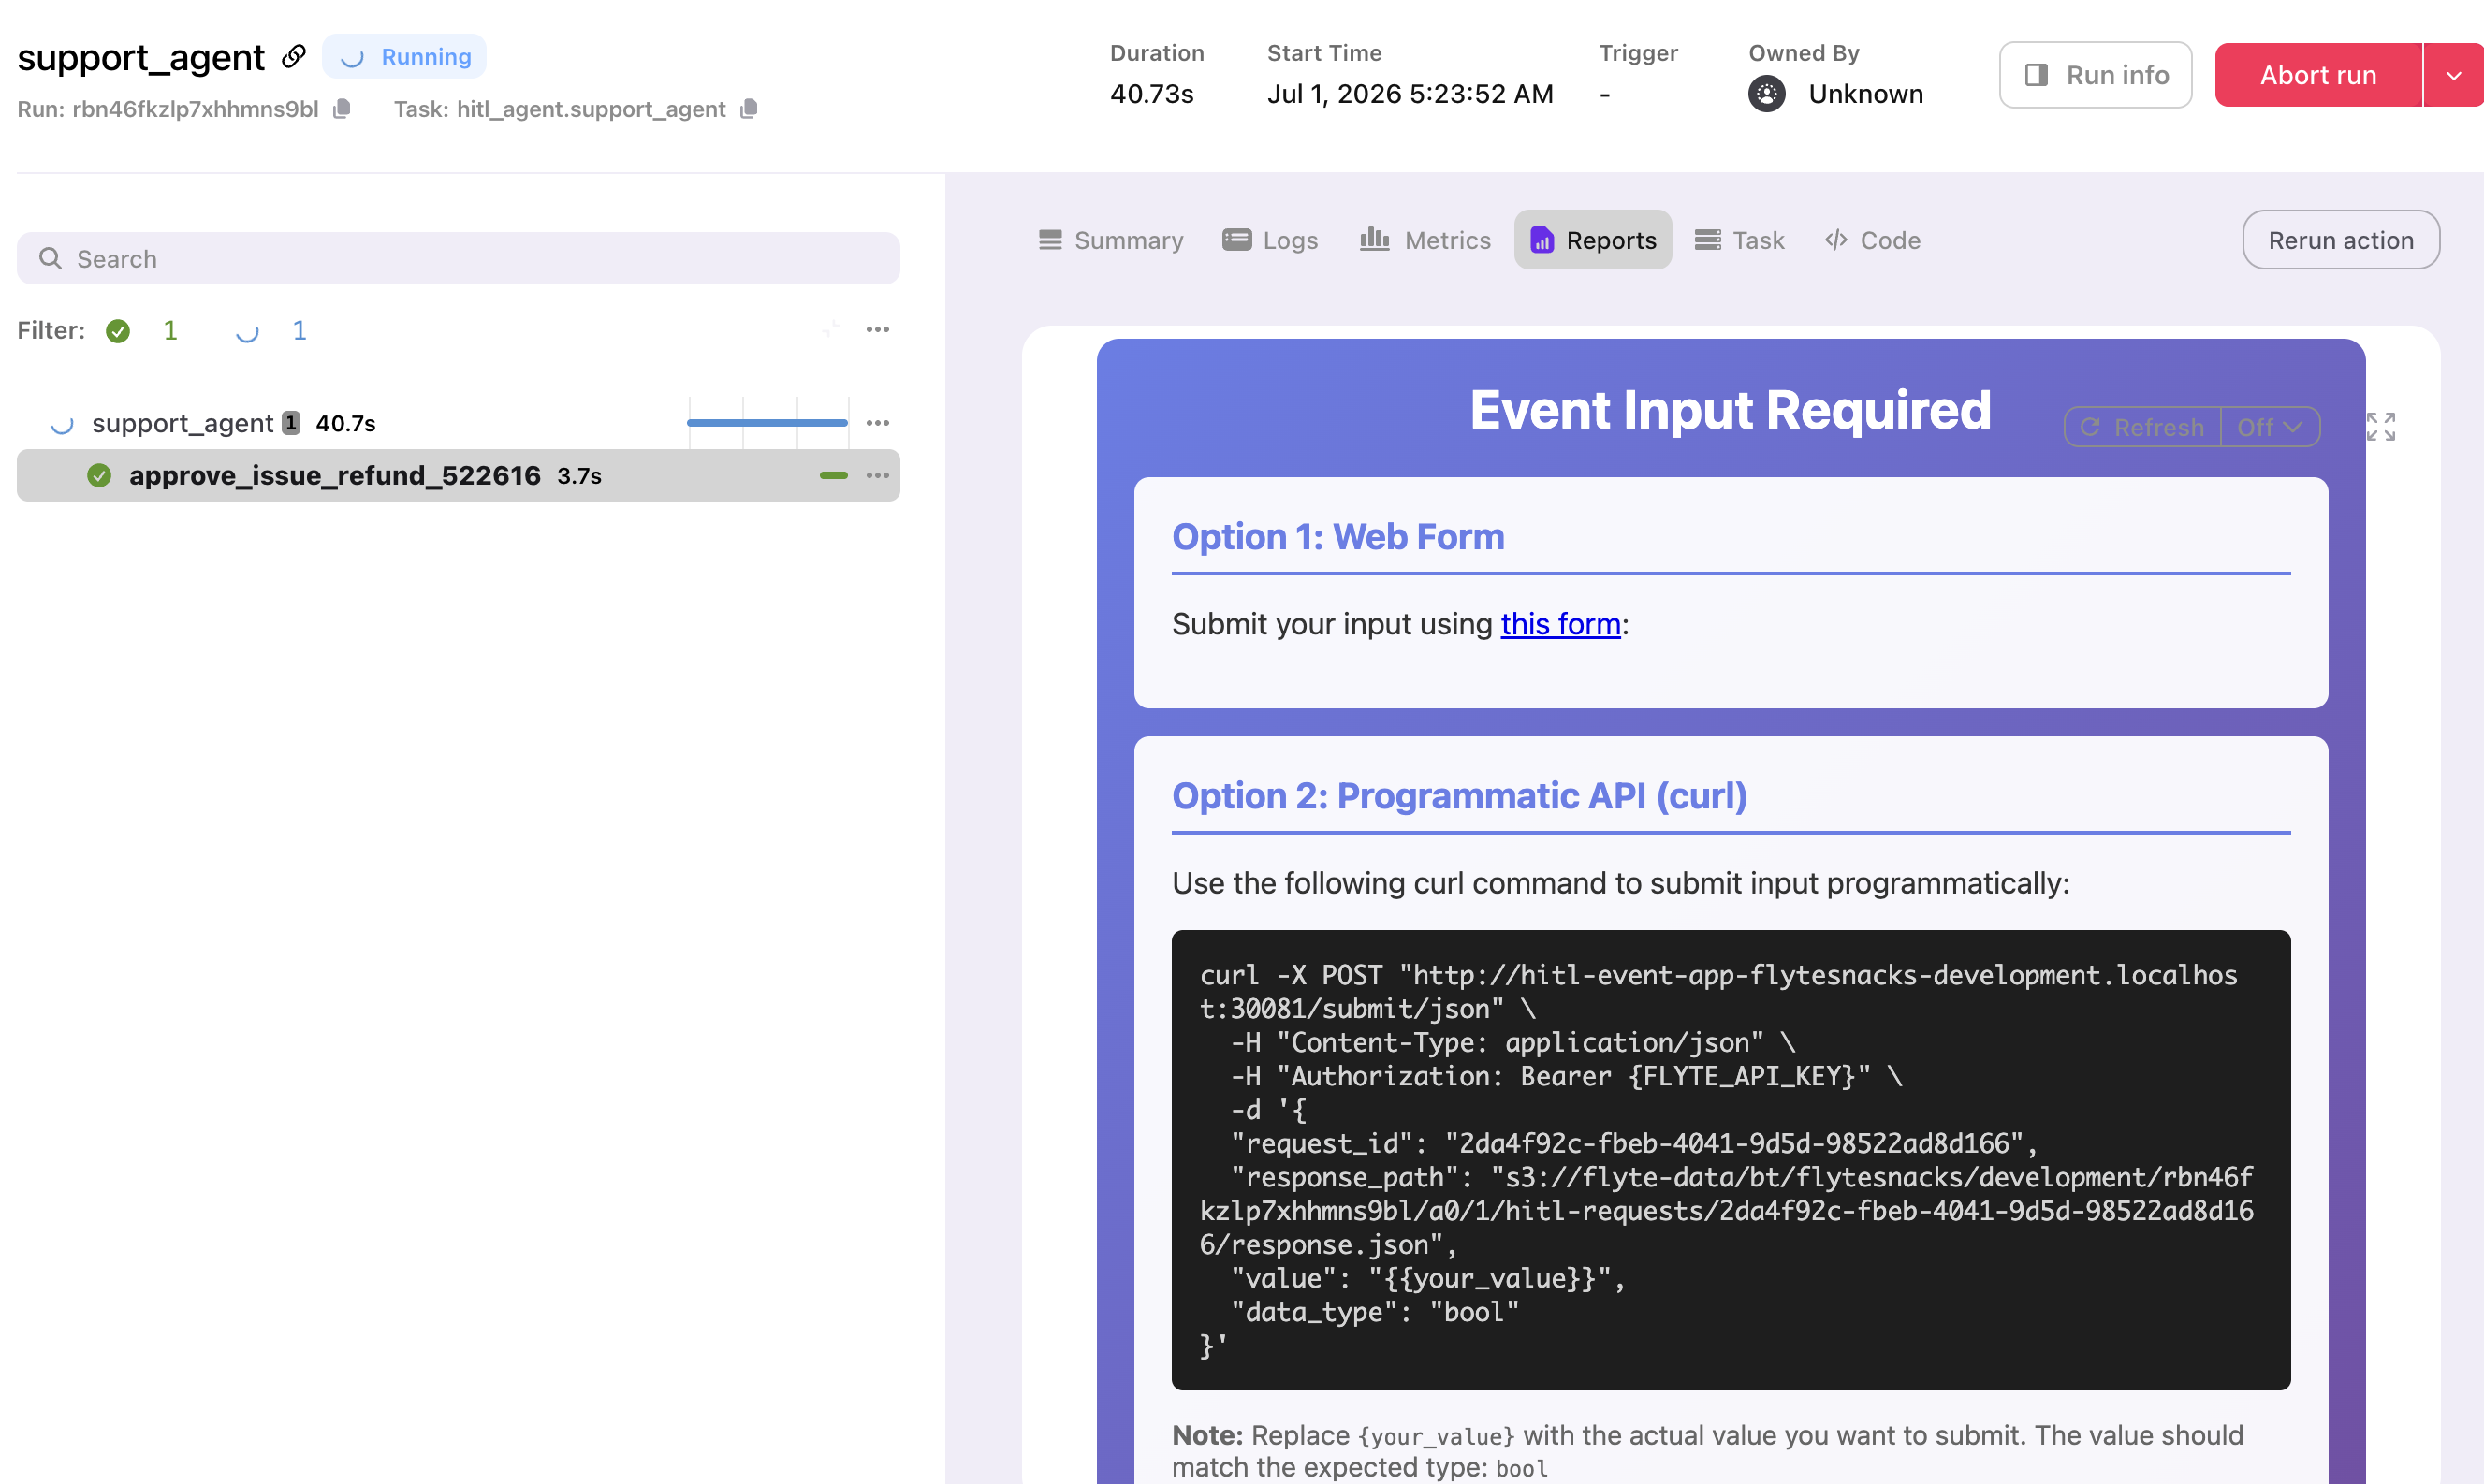

With the linked form enabling users to either approve or reject tool use. The execution remains Running but proceeds as soon as there's human input:

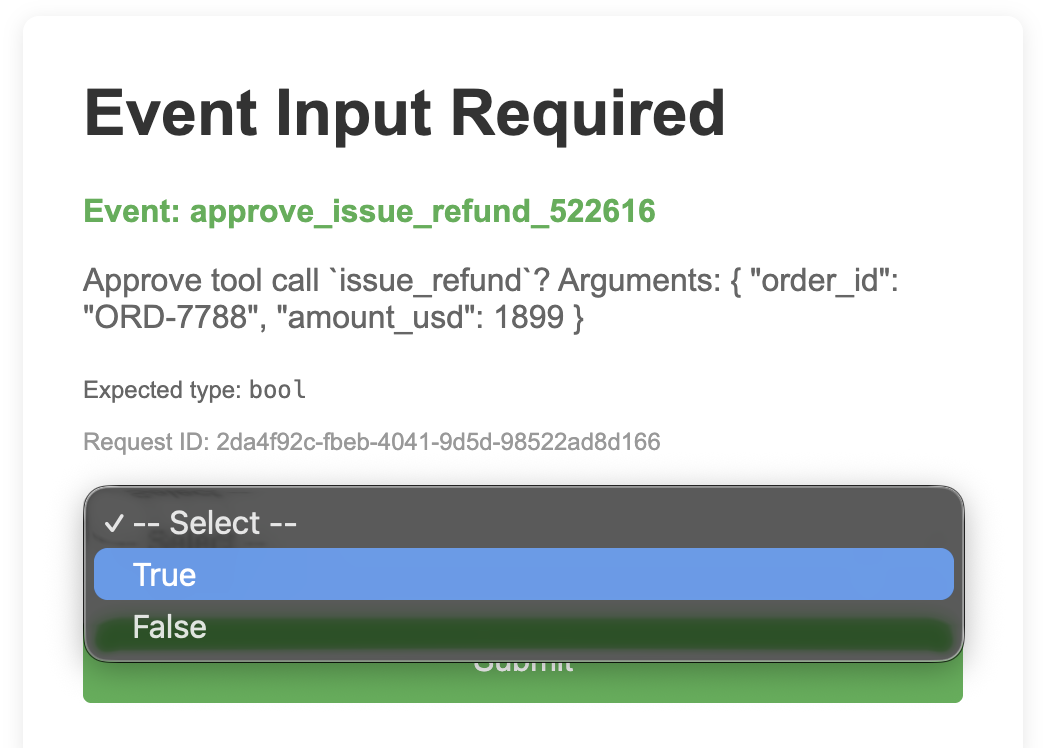

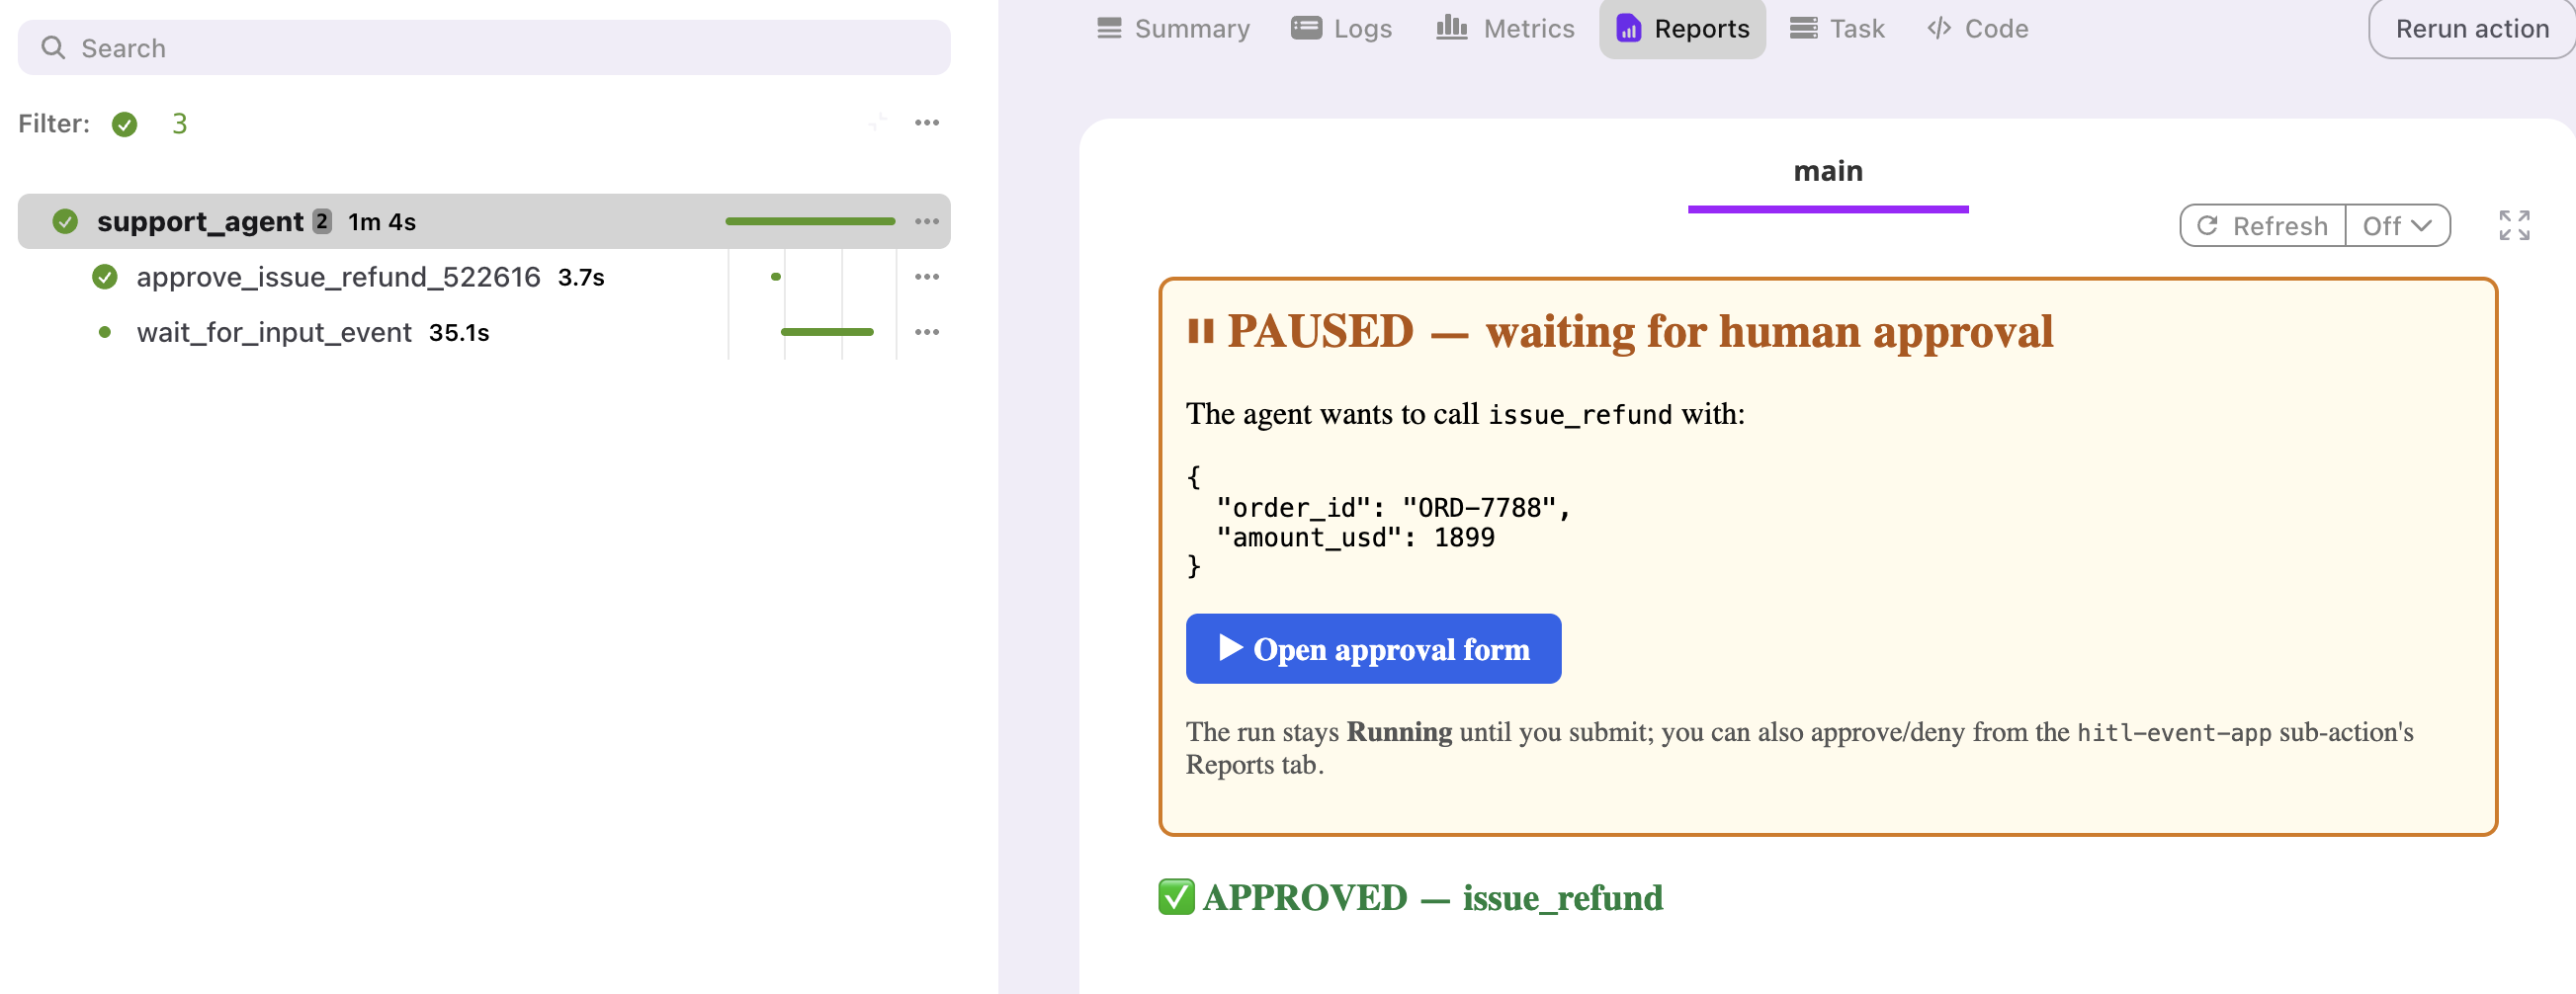